# **TP2 - Fase 2: Utilização de LLM para Agrupamento (Clustering)**

**Alunos:** Dara Oliveira e Fabrício Costa  
**Objetivo:** Aplicar técnicas de agrupamento no dataset Bank Marketing utilizando Large Language Models para auxiliar no processo.

---

## **1. Business Understanding**

### **Objetivo do Dataset**

O dataset "Bank Marketing" contém informações sobre campanhas de marketing telefônico realizadas por um banco português entre maio de 2008 e novembro de 2010. O objetivo original era prever se clientes iriam aderir a um depósito a prazo.

Para nosso trabalho de clustering, utilizaremos esses dados para **identificar diferentes perfis de clientes** com base em suas características demográficas, socioeconômicas e comportamentais, sem usar a variável target (y).

### **Origem dos Dados**

- **Fonte:** UCI Machine Learning Repository - Bank Marketing Dataset
- **Autores:** Sérgio Moro (ISCTE-IUL), Paulo Cortez (Univ. Minho) e Paulo Rita (ISCTE-IUL)
- **Referência:** [Moro et al., 2014] - "A Data-Driven Approach to Predict the Success of Bank Telemarketing"
- **Link:** http://archive.ics.uci.edu/ml/datasets/Bank+Marketing

### **Características do Dataset**

O dataset possui **20 variáveis de entrada + 1 variável target**, totalizando **41.188 instâncias** no arquivo completo:

**Dados do Cliente:**
- age, job, marital, education, default, housing, loan

**Dados da Campanha:**
- contact, month, day_of_week, duration, campaign, pdays, previous, poutcome

**Indicadores Socioeconômicos:**
- emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed

### **Relação com o Problema de Negócio**

A aplicação de clustering neste dataset permite:

1. **Segmentação de Clientes:** Identificar grupos naturais de clientes com características similares
2. **Estratégias de Marketing:** Personalizar abordagens para diferentes perfis
3. **Gestão de Risco:** Identificar grupos com comportamentos financeiros distintos
4. **Desenvolvimento de Produtos:** Criar ofertas adequadas para cada segmento

### **Justificativa para Clustering**

O clustering é adequado aqui porque:
- Queremos descobrir padrões ocultos nos dados sem supervisão
- Não há grupos pré-definidos de clientes
- Buscamos insights exploratórios sobre a base de clientes
- Os resultados podem guiar decisões estratégicas futuras

---

In [5]:
# Imports necessários para análise de dados e clustering
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
import warnings
warnings.filterwarnings('ignore')

# Configurações de visualização
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## **2. Data Understanding & Data Preparation**

### **2.1 Carregamento dos Dados**

Vamos começar carregando o dataset e fazendo uma análise inicial de sua estrutura.

In [6]:
# Carregando o dataset
# Nota: O arquivo usa separador ';' conforme documentação
df = pd.read_csv('data/bank-additional/bank-additional-full.csv', sep=';')

print("Dataset carregado com sucesso!")
print(f"Formato do dataset: {df.shape}")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
print("\nPrimeiras 5 linhas:")
df.head()

Dataset carregado com sucesso!
Formato do dataset: (41188, 21)
Número de linhas: 41188
Número de colunas: 21

Primeiras 5 linhas:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
# Informações gerais sobre o dataset
print("=== INFORMAÇÕES GERAIS DO DATASET ===")
print(f"Forma: {df.shape}")
print(f"\nTipos de dados:")
print(df.dtypes)
print(f"\nInformações sobre valores nulos:")
print(df.isnull().sum())
print(f"\nResumo estatístico das variáveis numéricas:")
df.describe()

=== INFORMAÇÕES GERAIS DO DATASET ===
Forma: (41188, 21)

Tipos de dados:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

Informações sobre valores nulos:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.i

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [8]:
# Análise das variáveis categóricas
print("=== ANÁLISE DAS VARIÁVEIS CATEGÓRICAS ===")
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"Variáveis categóricas encontradas: {list(categorical_cols)}")

for col in categorical_cols:
    print(f"\n--- {col.upper()} ---")
    print(f"Valores únicos: {df[col].nunique()}")
    print(f"Distribuição:")
    print(df[col].value_counts())
    print("-" * 50)

=== ANÁLISE DAS VARIÁVEIS CATEGÓRICAS ===
Variáveis categóricas encontradas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

--- JOB ---
Valores únicos: 12
Distribuição:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64
--------------------------------------------------

--- MARITAL ---
Valores únicos: 4
Distribuição:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64
--------------------------------------------------

--- EDUCATION ---
Valores únicos: 8
Distribuição:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y               

### **2.2 Data Preparation**

#### **2.2.1 Remoção de Variáveis Inadequadas para Clustering**

Conforme documentação, vamos remover:
- **y**: Variável target (não usamos em clustering não supervisionado)
- **duration**: Só conhecida após o fim da chamada (não realista para clustering preditivo)

Também vamos analisar se **pdays** (999 = não contatado) deve ser tratada especialmente.

In [9]:
# Criando cópia dos dados para clustering
df_cluster = df.copy()

# Removendo variáveis inadequadas para clustering
print("=== REMOÇÃO DE VARIÁVEIS ===")
print(f"Dataset original: {df_cluster.shape}")

# Remover variável target e duration
df_cluster = df_cluster.drop(['y', 'duration'], axis=1)
print(f"Após remoção de 'y' e 'duration': {df_cluster.shape}")

# Analisar a variável pdays (999 significa "não foi contatado anteriormente")
print(f"\nDistribuição de pdays:")
print(f"Valor 999 (não contatado): {(df_cluster['pdays'] == 999).sum()}")
print(f"Outros valores: {(df_cluster['pdays'] != 999).sum()}")

# Criar variável binária para "foi contatado anteriormente"
df_cluster['was_contacted_before'] = (df_cluster['pdays'] != 999).astype(int)
print(f"\nVariável 'was_contacted_before' criada:")
print(df_cluster['was_contacted_before'].value_counts())

# Para pdays, vamos substituir 999 por um valor mais representativo (ex: mediana dos valores != 999)
pdays_median = df_cluster[df_cluster['pdays'] != 999]['pdays'].median()
print(f"Mediana dos pdays != 999: {pdays_median}")
df_cluster['pdays_processed'] = df_cluster['pdays'].replace(999, pdays_median)

print(f"\nDataset preparado: {df_cluster.shape}")
df_cluster.head()

=== REMOÇÃO DE VARIÁVEIS ===
Dataset original: (41188, 21)
Após remoção de 'y' e 'duration': (41188, 19)

Distribuição de pdays:
Valor 999 (não contatado): 39673
Outros valores: 1515

Variável 'was_contacted_before' criada:
was_contacted_before
0    39673
1     1515
Name: count, dtype: int64
Mediana dos pdays != 999: 6.0

Dataset preparado: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,pdays_processed
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,6
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,6
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,6
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,6
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0,6


#### **2.2.2 Tratamento de Variáveis Categóricas**

Para aplicar algoritmos de clustering, precisamos converter variáveis categóricas em numéricas. Vamos usar:
- **Label Encoding** para variáveis ordinais
- **One-Hot Encoding** para variáveis nominais com poucas categorias
- **Target Encoding** ou agrupamento para variáveis com muitas categorias

In [10]:
# Identificar variáveis categóricas
categorical_cols = df_cluster.select_dtypes(include=['object']).columns.tolist()
print("=== TRATAMENTO DE VARIÁVEIS CATEGÓRICAS ===")
print(f"Variáveis categóricas: {categorical_cols}")

# Separar por tipo de encoding necessário
# Variáveis ordinais (Label Encoding)
ordinal_vars = ['education']  # education tem ordem implícita

# Variáveis nominais com poucas categorias (One-Hot Encoding)
nominal_few_cats = ['marital', 'default', 'housing', 'loan', 'contact', 'poutcome']

# Variáveis nominais com muitas categorias (Target/Frequency Encoding)
nominal_many_cats = ['job', 'month', 'day_of_week']

print(f"\nOrdinais (Label Encoding): {ordinal_vars}")
print(f"Nominais poucas cats (One-Hot): {nominal_few_cats}")
print(f"Nominais muitas cats (Frequency): {nominal_many_cats}")

# 1. EDUCATION - Label Encoding com ordem
education_order = ['illiterate', 'basic.4y', 'basic.6y', 'basic.9y', 'high.school', 
                   'professional.course', 'university.degree', 'unknown']
education_mapping = {edu: i for i, edu in enumerate(education_order)}
df_cluster['education_encoded'] = df_cluster['education'].map(education_mapping)

print(f"\nEducation mapping: {education_mapping}")

# 2. One-Hot Encoding para variáveis nominais com poucas categorias
df_encoded = df_cluster.copy()

for var in nominal_few_cats:
    if var in df_encoded.columns:
        # Criar dummies
        dummies = pd.get_dummies(df_encoded[var], prefix=var, drop_first=True)
        df_encoded = pd.concat([df_encoded, dummies], axis=1)
        print(f"One-hot encoding para '{var}': {dummies.columns.tolist()}")

# 3. Frequency Encoding para variáveis com muitas categorias
for var in nominal_many_cats:
    if var in df_encoded.columns:
        freq_map = df_encoded[var].value_counts().to_dict()
        df_encoded[f'{var}_freq'] = df_encoded[var].map(freq_map)
        print(f"Frequency encoding para '{var}': {var}_freq")

print(f"\nDataset após encoding: {df_encoded.shape}")
df_encoded.head()

=== TRATAMENTO DE VARIÁVEIS CATEGÓRICAS ===
Variáveis categóricas: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Ordinais (Label Encoding): ['education']
Nominais poucas cats (One-Hot): ['marital', 'default', 'housing', 'loan', 'contact', 'poutcome']
Nominais muitas cats (Frequency): ['job', 'month', 'day_of_week']

Education mapping: {'illiterate': 0, 'basic.4y': 1, 'basic.6y': 2, 'basic.9y': 3, 'high.school': 4, 'professional.course': 5, 'university.degree': 6, 'unknown': 7}
One-hot encoding para 'marital': ['marital_married', 'marital_single', 'marital_unknown']
One-hot encoding para 'default': ['default_unknown', 'default_yes']
One-hot encoding para 'housing': ['housing_unknown', 'housing_yes']
One-hot encoding para 'loan': ['loan_unknown', 'loan_yes']
One-hot encoding para 'contact': ['contact_telephone']
One-hot encoding para 'poutcome': ['poutcome_nonexistent', 'poutcome_success']
Frequency encoding para 'job': job_

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,poutcome_nonexistent,poutcome_success,job_freq,month_freq,day_of_week_freq
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,False,False,False,False,True,True,False,1060,13769,8514
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,False,False,False,False,True,True,False,3969,13769,8514
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,False,True,False,False,True,True,False,3969,13769,8514
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,False,False,False,False,True,True,False,10422,13769,8514
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,False,False,False,True,True,True,False,3969,13769,8514


In [11]:
# Remover colunas categóricas originais e manter apenas as encodadas
cols_to_drop = categorical_cols + ['pdays']  # pdays original também
df_final = df_encoded.drop(columns=cols_to_drop)

print("=== DATASET FINAL PARA CLUSTERING ===")
print(f"Forma final: {df_final.shape}")
print(f"Colunas finais: {list(df_final.columns)}")

# Verificar tipos de dados
print(f"\nTipos de dados:")
print(df_final.dtypes.value_counts())

# Verificar se há valores nulos
print(f"\nValores nulos:")
print(df_final.isnull().sum().sum())

df_final.head()

=== DATASET FINAL PARA CLUSTERING ===
Forma final: (41188, 26)
Colunas finais: ['age', 'campaign', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_contacted_before', 'pdays_processed', 'education_encoded', 'marital_married', 'marital_single', 'marital_unknown', 'default_unknown', 'default_yes', 'housing_unknown', 'housing_yes', 'loan_unknown', 'loan_yes', 'contact_telephone', 'poutcome_nonexistent', 'poutcome_success', 'job_freq', 'month_freq', 'day_of_week_freq']

Tipos de dados:
bool       12
int64       8
float64     5
int32       1
Name: count, dtype: int64

Valores nulos:
0


,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,pdays_processed,...,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,poutcome_nonexistent,poutcome_success,job_freq,month_freq,day_of_week_freq
0,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,6,...,False,False,False,False,True,True,False,1060,13769,8514
1,57,1,0,1.1,93.994,-36.4,4.857,5191.0,0,6,...,False,False,False,False,True,True,False,3969,13769,8514
2,37,1,0,1.1,93.994,-36.4,4.857,5191.0,0,6,...,False,True,False,False,True,True,False,3969,13769,8514
3,40,1,0,1.1,93.994,-36.4,4.857,5191.0,0,6,...,False,False,False,False,True,True,False,10422,13769,8514
4,56,1,0,1.1,93.994,-36.4,4.857,5191.0,0,6,...,False,False,False,True,True,True,False,3969,13769,8514


#### **2.2.3 Normalização dos Dados**

Como os algoritmos de clustering são sensíveis à escala das variáveis, precisamos normalizar os dados. Vamos usar **StandardScaler** para padronizar todas as variáveis (média = 0, desvio = 1).

In [12]:
# Normalização dos dados usando StandardScaler
scaler = StandardScaler()
df_scaled = pd.DataFrame(
    scaler.fit_transform(df_final), 
    columns=df_final.columns,
    index=df_final.index
)

print("=== NORMALIZAÇÃO DOS DADOS ===")
print(f"Dataset normalizado: {df_scaled.shape}")
print(f"\nEstatísticas após normalização:")
print(df_scaled.describe().round(4))

# Verificar se a normalização funcionou (médias próximas de 0, std próximos de 1)
print(f"\nVerificação da normalização:")
print(f"Médias próximas de 0: {(abs(df_scaled.mean()) < 0.001).all()}")
print(f"Desvios próximos de 1: {(abs(df_scaled.std() - 1) < 0.001).all()}")

df_scaled.head()

=== NORMALIZAÇÃO DOS DADOS ===
Dataset normalizado: (41188, 26)

Estatísticas após normalização:
              age    campaign    previous  emp.var.rate  cons.price.idx  \
count  41188.0000  41188.0000  41188.0000    41188.0000      41188.0000   
mean      -0.0000     -0.0000      0.0000        0.0000         -0.0000   
std        1.0000      1.0000      1.0000        1.0000          1.0000   
min       -2.2094     -0.5659     -0.3495       -2.2164         -2.3749   
25%       -0.7700     -0.5659     -0.3495       -1.1979         -0.8650   
50%       -0.1942     -0.2049     -0.3495        0.6481          0.2995   
75%        0.6694      0.1561     -0.3495        0.8391          0.7227   
max        5.5633     19.2898     13.7949        0.8391          2.0582   

       cons.conf.idx   euribor3m  nr.employed  was_contacted_before  \
count     41188.0000  41188.0000   41188.0000            41188.0000   
mean         -0.0000      0.0000      -0.0000               -0.0000   
std           

,age,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,was_contacted_before,pdays_processed,...,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,poutcome_nonexistent,poutcome_success,job_freq,month_freq,day_of_week_freq
0,1.533034,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.195415,-0.000728,...,-0.156933,-1.048877,-0.156933,-0.422872,1.31827,0.397706,-0.1857,-1.593680,1.317138,0.911397
1,1.628993,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.195415,-0.000728,...,-0.156933,-1.048877,-0.156933,-0.422872,1.31827,0.397706,-0.1857,-0.765235,1.317138,0.911397
2,-0.290186,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.195415,-0.000728,...,-0.156933,0.953401,-0.156933,-0.422872,1.31827,0.397706,-0.1857,-0.765235,1.317138,0.911397
3,-0.002309,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.195415,-0.000728,...,-0.156933,-1.048877,-0.156933,-0.422872,1.31827,0.397706,-0.1857,1.072493,1.317138,0.911397
4,1.533034,-0.565922,-0.349494,0.648092,0.722722,0.886447,0.71246,0.33168,-0.195415,-0.000728,...,-0.156933,-1.048877,-0.156933,2.364781,1.31827,0.397706,-0.1857,-0.765235,1.317138,0.911397


## **3. Modeling**

### **3.1 Análise de Componentes Principais (PCA)**

Antes de aplicar os algoritmos de clustering, vamos fazer uma análise PCA para:
1. Reduzir a dimensionalidade dos dados
2. Visualizar os dados em 2D/3D
3. Entender quais variáveis mais contribuem para a variância

=== ANÁLISE PCA ===
Número total de componentes: 26
Variância explicada pelos primeiros 10 componentes:
PC1: 0.1903 (0.1903 acumulada)
PC2: 0.0855 (0.2757 acumulada)
PC3: 0.0795 (0.3552 acumulada)
PC4: 0.0761 (0.4313 acumulada)
PC5: 0.0509 (0.4822 acumulada)
PC6: 0.0438 (0.5260 acumulada)
PC7: 0.0406 (0.5666 acumulada)
PC8: 0.0396 (0.6062 acumulada)
PC9: 0.0387 (0.6450 acumulada)
PC10: 0.0384 (0.6834 acumulada)

Componentes para 80% da variância: 14
Componentes para 90% da variância: 17


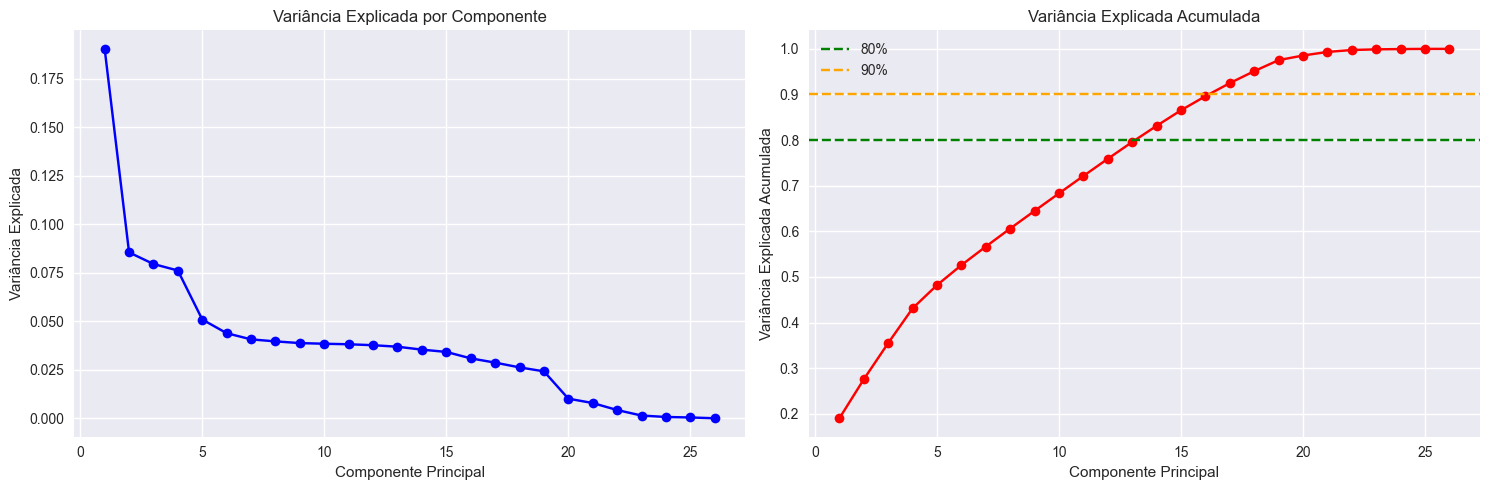


Dataset PCA (90% variância): (41188, 17)


In [13]:
# Análise de Componentes Principais (PCA)
pca = PCA()
pca_result = pca.fit_transform(df_scaled)

# Calcular variância explicada acumulada
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("=== ANÁLISE PCA ===")
print(f"Número total de componentes: {len(pca.explained_variance_ratio_)}")
print(f"Variância explicada pelos primeiros 10 componentes:")
for i in range(min(10, len(pca.explained_variance_ratio_))):
    print(f"PC{i+1}: {pca.explained_variance_ratio_[i]:.4f} ({cumulative_variance[i]:.4f} acumulada)")

# Encontrar número de componentes para explicar 80% e 90% da variância
n_80 = np.argmax(cumulative_variance >= 0.80) + 1
n_90 = np.argmax(cumulative_variance >= 0.90) + 1
print(f"\nComponentes para 80% da variância: {n_80}")
print(f"Componentes para 90% da variância: {n_90}")

# Visualizar variância explicada
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, 'bo-')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada')
plt.title('Variância Explicada por Componente')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-')
plt.axhline(y=0.8, color='g', linestyle='--', label='80%')
plt.axhline(y=0.9, color='orange', linestyle='--', label='90%')
plt.xlabel('Componente Principal')
plt.ylabel('Variância Explicada Acumulada')
plt.title('Variância Explicada Acumulada')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Preparar dados PCA para clustering (usando componentes que explicam 90% da variância)
pca_90 = PCA(n_components=n_90)
df_pca = pca_90.fit_transform(df_scaled)
print(f"\nDataset PCA (90% variância): {df_pca.shape}")

### **3.2 Determinação do Número Ótimo de Clusters**

Vamos usar diferentes métodos para determinar o número ideal de clusters:
1. **Método do Cotovelo (Elbow Method)**
2. **Silhouette Score**
3. **Gap Statistic** (opcional)

=== DETERMINAÇÃO DO NÚMERO ÓTIMO DE CLUSTERS ===
Testando diferentes valores de k...
k=2: Inertia=902987.00, Silhouette=0.2220
k=3: Inertia=812065.40, Silhouette=0.2148
k=4: Inertia=767650.68, Silhouette=0.1271
k=5: Inertia=707401.49, Silhouette=0.1474
k=6: Inertia=659300.98, Silhouette=0.1337
k=7: Inertia=637377.32, Silhouette=0.1374
k=8: Inertia=592824.02, Silhouette=0.1380
k=9: Inertia=552594.86, Silhouette=0.1555
k=10: Inertia=546458.55, Silhouette=0.1452


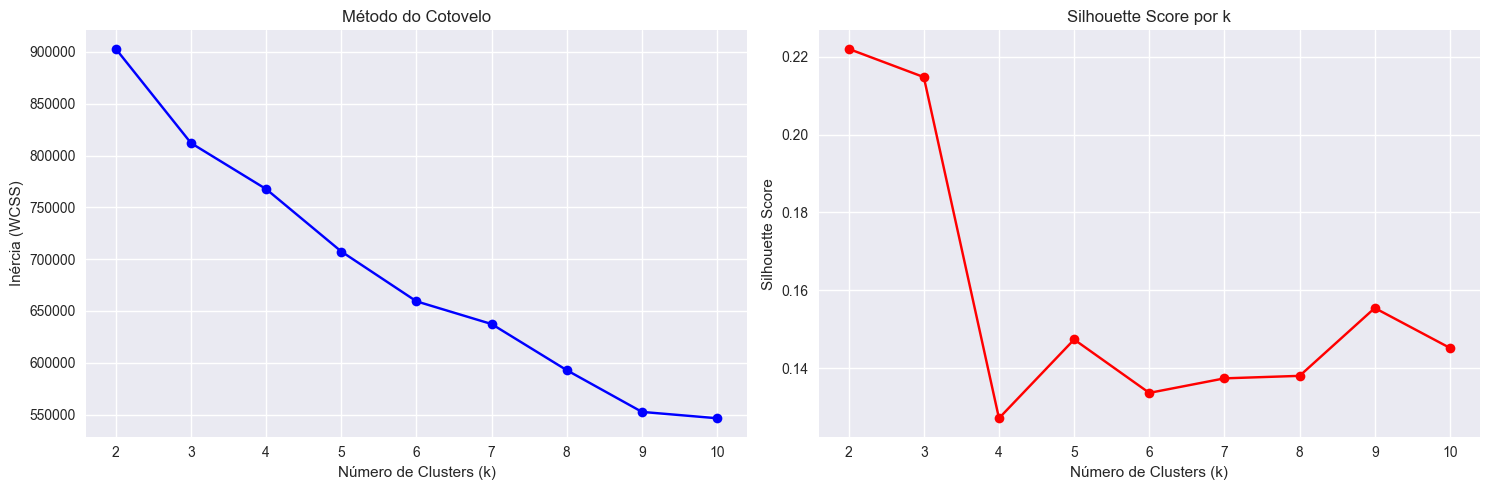


Número ótimo de clusters (Silhouette): 2
Melhor Silhouette Score: 0.2220


In [14]:
# Determinação do número ótimo de clusters
def find_optimal_clusters(data, max_k=10):
    """
    Função para encontrar número ótimo de clusters usando Elbow Method e Silhouette Score
    """
    inertias = []
    silhouette_scores = []
    k_range = range(2, max_k + 1)
    
    print("=== DETERMINAÇÃO DO NÚMERO ÓTIMO DE CLUSTERS ===")
    print("Testando diferentes valores de k...")
    
    for k in k_range:
        # K-Means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        cluster_labels = kmeans.fit_predict(data)
        
        # Métricas
        inertia = kmeans.inertia_
        silhouette_avg = silhouette_score(data, cluster_labels)
        
        inertias.append(inertia)
        silhouette_scores.append(silhouette_avg)
        
        print(f"k={k}: Inertia={inertia:.2f}, Silhouette={silhouette_avg:.4f}")
    
    return k_range, inertias, silhouette_scores

# Testar com dados originais normalizados
k_range, inertias, silhouette_scores = find_optimal_clusters(df_scaled, max_k=10)

# Visualizar resultados
plt.figure(figsize=(15, 5))

# Método do Cotovelo
plt.subplot(1, 2, 1)
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo')
plt.grid(True)

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score por k')
plt.grid(True)

plt.tight_layout()
plt.show()

# Encontrar k ótimo baseado no Silhouette Score
optimal_k = k_range[np.argmax(silhouette_scores)]
max_silhouette = max(silhouette_scores)
print(f"\nNúmero ótimo de clusters (Silhouette): {optimal_k}")
print(f"Melhor Silhouette Score: {max_silhouette:.4f}")

### **3.3 Aplicação dos Algoritmos de Clustering**

Vamos aplicar três algoritmos diferentes conforme proposto:
1. **K-Means** - Para grupos bem definidos e centrados
2. **DBSCAN** - Para descobrir grupos com formas arbitrárias e tratar ruído
3. **Clustering Hierárquico** - Para análise hierárquica dos clusters

In [15]:
# 1. K-MEANS CLUSTERING
print("=== 1. K-MEANS CLUSTERING ===")

# Aplicar K-Means com o número ótimo de clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(df_scaled)

# Métricas do K-Means
kmeans_silhouette = silhouette_score(df_scaled, kmeans_labels)
kmeans_inertia = kmeans.inertia_

print(f"Número de clusters: {optimal_k}")
print(f"Silhouette Score: {kmeans_silhouette:.4f}")
print(f"Inércia: {kmeans_inertia:.2f}")
print(f"Distribuição dos clusters:")
unique, counts = np.unique(kmeans_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} clientes ({count/len(kmeans_labels)*100:.1f}%)")

# Adicionar labels ao dataframe original para análise
df_results = df.copy()
df_results['kmeans_cluster'] = kmeans_labels

print(f"\nPrimeiras características dos clusters K-Means:")
df_results.groupby('kmeans_cluster')[['age', 'campaign', 'previous']].mean().round(2)

=== 1. K-MEANS CLUSTERING ===
Número de clusters: 2
Silhouette Score: 0.2220
Inércia: 902987.00
Distribuição dos clusters:
  Cluster 0: 26960 clientes (65.5%)
  Cluster 1: 14228 clientes (34.5%)

Primeiras características dos clusters K-Means:


,age,campaign,previous
kmeans_cluster,,,
0,40.17,2.82,0.0
1,39.75,2.08,0.5


=== 2. DBSCAN CLUSTERING ===


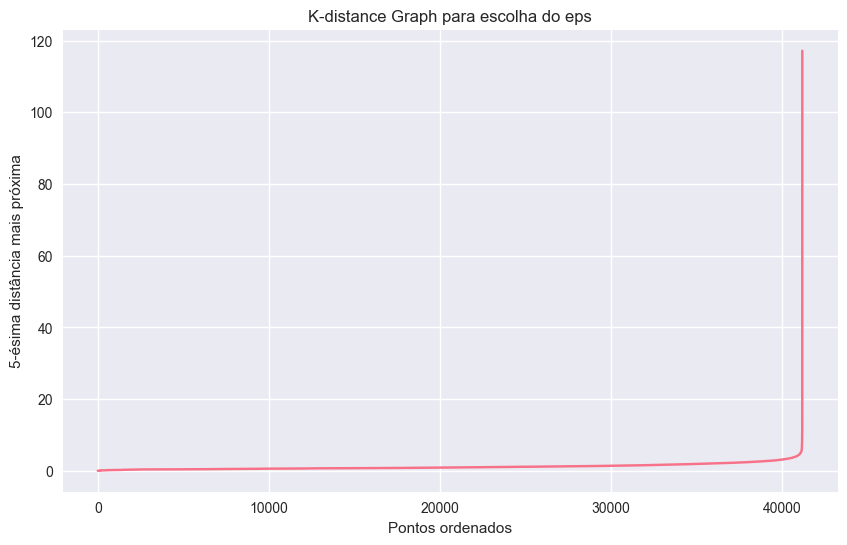

Eps estimado: 2.7183
Número de clusters encontrados: 24
Número de pontos de ruído: 1305 (3.2%)
Silhouette Score (sem ruído): 0.0906
Distribuição dos clusters DBSCAN:
  Ruído: 1305 clientes (3.2%)
  Cluster 0: 29174 clientes (70.8%)
  Cluster 1: 5286 clientes (12.8%)
  Cluster 2: 803 clientes (1.9%)
  Cluster 3: 4 clientes (0.0%)
  Cluster 4: 5 clientes (0.0%)
  Cluster 5: 8 clientes (0.0%)
  Cluster 6: 3270 clientes (7.9%)
  Cluster 7: 546 clientes (1.3%)
  Cluster 8: 7 clientes (0.0%)
  Cluster 9: 5 clientes (0.0%)
  Cluster 10: 57 clientes (0.1%)
  Cluster 11: 616 clientes (1.5%)
  Cluster 12: 43 clientes (0.1%)
  Cluster 13: 8 clientes (0.0%)
  Cluster 14: 6 clientes (0.0%)
  Cluster 15: 6 clientes (0.0%)
  Cluster 16: 4 clientes (0.0%)
  Cluster 17: 5 clientes (0.0%)
  Cluster 18: 5 clientes (0.0%)
  Cluster 19: 6 clientes (0.0%)
  Cluster 20: 5 clientes (0.0%)
  Cluster 21: 4 clientes (0.0%)
  Cluster 22: 5 clientes (0.0%)
  Cluster 23: 5 clientes (0.0%)


In [16]:
# 2. DBSCAN CLUSTERING
print("=== 2. DBSCAN CLUSTERING ===")

# Determinar parâmetros eps e min_samples para DBSCAN
from sklearn.neighbors import NearestNeighbors

# Método k-distance para determinar eps
k = 5  # min_samples recomendado
neighbors = NearestNeighbors(n_neighbors=k)
neighbors_fit = neighbors.fit(df_scaled)
distances, indices = neighbors_fit.kneighbors(df_scaled)
distances = np.sort(distances[:, k-1], axis=0)

# Plotar k-distance para escolher eps
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.xlabel('Pontos ordenados')
plt.ylabel(f'{k}-ésima distância mais próxima')
plt.title('K-distance Graph para escolha do eps')
plt.grid(True)
plt.show()

# Escolher eps baseado no "cotovelo" do gráfico (aproximadamente)
eps_value = np.percentile(distances, 95)  # 95th percentile como estimativa
print(f"Eps estimado: {eps_value:.4f}")

# Aplicar DBSCAN
dbscan = DBSCAN(eps=eps_value, min_samples=k)
dbscan_labels = dbscan.fit_predict(df_scaled)

# Métricas do DBSCAN
n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)

print(f"Número de clusters encontrados: {n_clusters_dbscan}")
print(f"Número de pontos de ruído: {n_noise} ({n_noise/len(dbscan_labels)*100:.1f}%)")

if n_clusters_dbscan > 1:
    # Calcular silhouette apenas para pontos não-ruído
    non_noise_mask = dbscan_labels != -1
    if np.sum(non_noise_mask) > 0:
        dbscan_silhouette = silhouette_score(df_scaled[non_noise_mask], dbscan_labels[non_noise_mask])
        print(f"Silhouette Score (sem ruído): {dbscan_silhouette:.4f}")

print(f"Distribuição dos clusters DBSCAN:")
unique, counts = np.unique(dbscan_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    if cluster == -1:
        print(f"  Ruído: {count} clientes ({count/len(dbscan_labels)*100:.1f}%)")
    else:
        print(f"  Cluster {cluster}: {count} clientes ({count/len(dbscan_labels)*100:.1f}%)")

# Adicionar labels DBSCAN
df_results['dbscan_cluster'] = dbscan_labels

=== 3. CLUSTERING HIERÁRQUICO ===
Usando amostra de 1000 pontos para dendrograma


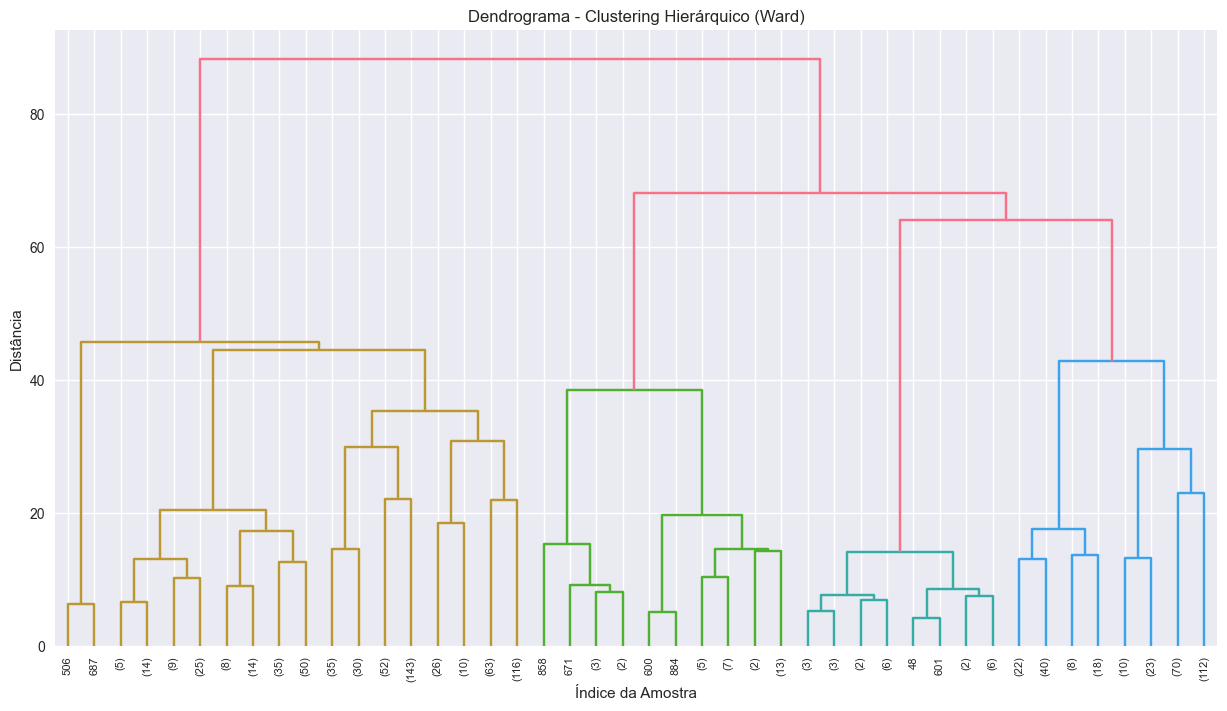

Número de clusters: 2
Silhouette Score: 0.2179
Distribuição dos clusters hierárquicos:
  Cluster 0: 13946 clientes (33.9%)
  Cluster 1: 27242 clientes (66.1%)

Primeiras características dos clusters Hierárquicos:


,age,campaign,previous
hierarchical_cluster,,,
0,39.77,2.09,0.50
1,40.16,2.81,0.01


In [17]:
# 3. CLUSTERING HIERÁRQUICO
print("=== 3. CLUSTERING HIERÁRQUICO ===")

# Para datasets grandes, vamos usar uma amostra para o dendrograma
sample_size = min(1000, len(df_scaled))
sample_indices = np.random.choice(len(df_scaled), sample_size, replace=False)
df_sample = df_scaled.iloc[sample_indices]

print(f"Usando amostra de {sample_size} pontos para dendrograma")

# Calcular linkage matrix
linkage_matrix = linkage(df_sample, method='ward')

# Plotar dendrograma
plt.figure(figsize=(15, 8))
dendrogram(linkage_matrix, truncate_mode='level', p=5)
plt.title('Dendrograma - Clustering Hierárquico (Ward)')
plt.xlabel('Índice da Amostra')
plt.ylabel('Distância')
plt.show()

# Aplicar clustering hierárquico no dataset completo
hierarchical = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hierarchical_labels = hierarchical.fit_predict(df_scaled)

# Métricas do Clustering Hierárquico
hierarchical_silhouette = silhouette_score(df_scaled, hierarchical_labels)

print(f"Número de clusters: {optimal_k}")
print(f"Silhouette Score: {hierarchical_silhouette:.4f}")
print(f"Distribuição dos clusters hierárquicos:")
unique, counts = np.unique(hierarchical_labels, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} clientes ({count/len(hierarchical_labels)*100:.1f}%)")

# Adicionar labels hierárquicos
df_results['hierarchical_cluster'] = hierarchical_labels

print(f"\nPrimeiras características dos clusters Hierárquicos:")
df_results.groupby('hierarchical_cluster')[['age', 'campaign', 'previous']].mean().round(2)

## **4. Evaluation**

### **4.1 Comparação dos Algoritmos**

Vamos comparar o desempenho dos três algoritmos usando diferentes métricas e visualizações.

=== COMPARAÇÃO DOS ALGORITMOS ===
     Algoritmo  Silhouette Score  N° Clusters  Pontos de Ruído
0      K-Means          0.222010            2                0
1       DBSCAN          0.090568           24             1305
2  Hierárquico          0.217914            2                0


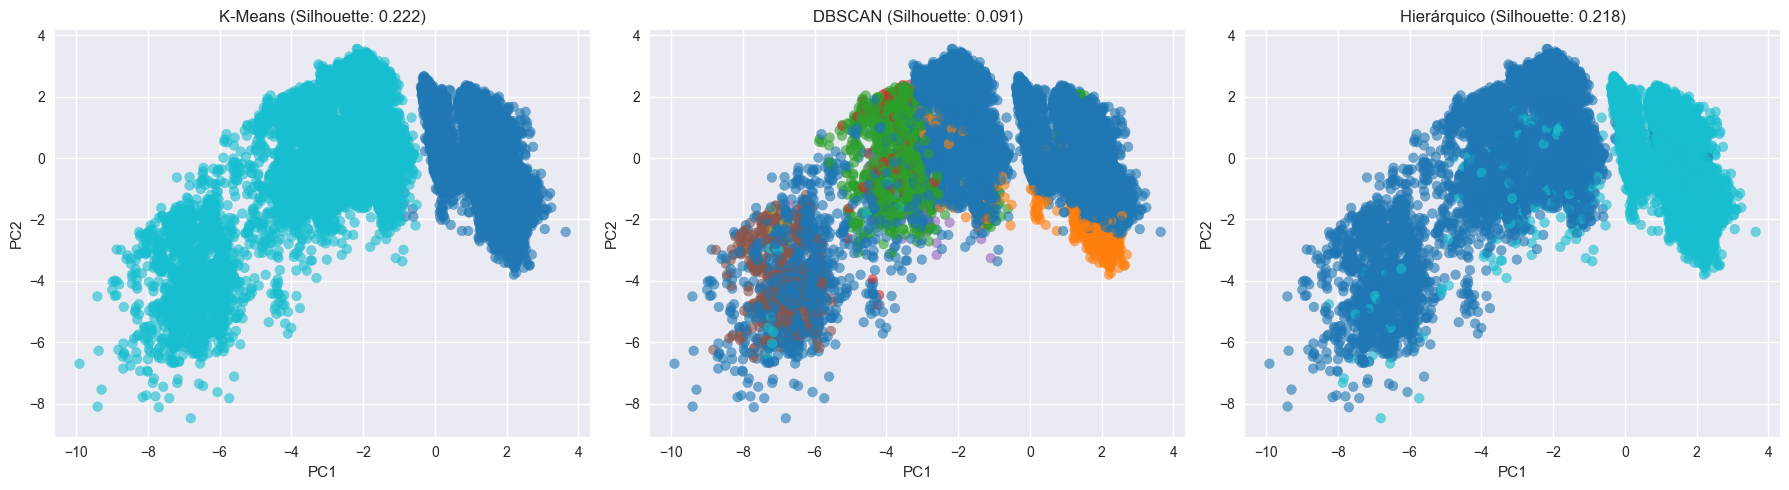


Variância explicada pelos 2 primeiros componentes: 0.276
PC1: 0.190
PC2: 0.085


In [18]:
# Comparação dos algoritmos
print("=== COMPARAÇÃO DOS ALGORITMOS ===")

# Resumo das métricas
algorithms_comparison = {
    'Algoritmo': ['K-Means', 'DBSCAN', 'Hierárquico'],
    'Silhouette Score': [kmeans_silhouette, 
                        dbscan_silhouette if n_clusters_dbscan > 1 else 'N/A',
                        hierarchical_silhouette],
    'N° Clusters': [optimal_k, n_clusters_dbscan, optimal_k],
    'Pontos de Ruído': [0, n_noise, 0]
}

comparison_df = pd.DataFrame(algorithms_comparison)
print(comparison_df)

# Visualização dos clusters em 2D usando PCA
pca_2d = PCA(n_components=2)
df_pca_2d = pca_2d.fit_transform(df_scaled)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# K-Means
scatter1 = axes[0].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=kmeans_labels, cmap='tab10', alpha=0.6)
axes[0].set_title(f'K-Means (Silhouette: {kmeans_silhouette:.3f})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# DBSCAN
scatter2 = axes[1].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=dbscan_labels, cmap='tab10', alpha=0.6)
axes[1].set_title(f'DBSCAN (Silhouette: {dbscan_silhouette:.3f})')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Hierárquico
scatter3 = axes[2].scatter(df_pca_2d[:, 0], df_pca_2d[:, 1], c=hierarchical_labels, cmap='tab10', alpha=0.6)
axes[2].set_title(f'Hierárquico (Silhouette: {hierarchical_silhouette:.3f})')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# Análise da variância explicada pelo PCA 2D
print(f"\nVariância explicada pelos 2 primeiros componentes: {sum(pca_2d.explained_variance_ratio_):.3f}")
print(f"PC1: {pca_2d.explained_variance_ratio_[0]:.3f}")
print(f"PC2: {pca_2d.explained_variance_ratio_[1]:.3f}")

### **4.2 Interpretação dos Clusters**

Vamos analisar as características de cada cluster para entender os perfis de clientes identificados.

=== ANÁLISE DETALHADA DOS CLUSTERS (K-MEANS) ===
Características médias por cluster:
                   age              job  marital          education  housing  \
                  mean     std <lambda> <lambda>           <lambda> <lambda>   
kmeans_cluster                                                                 
0               40.171   9.205   admin.  married  university.degree    0.503   
1               39.747  12.399   admin.  married  university.degree    0.564   

                   loan campaign        previous        emp.var.rate  \
               <lambda>     mean    std     mean    std         mean   
kmeans_cluster                                                         
0                 0.151    2.824  3.183      0.0  0.015        1.149   
1                 0.152    2.081  1.629      0.5  0.738       -1.940   

               cons.price.idx cons.conf.idx        y  
                         mean          mean <lambda>  
kmeans_cluster                             

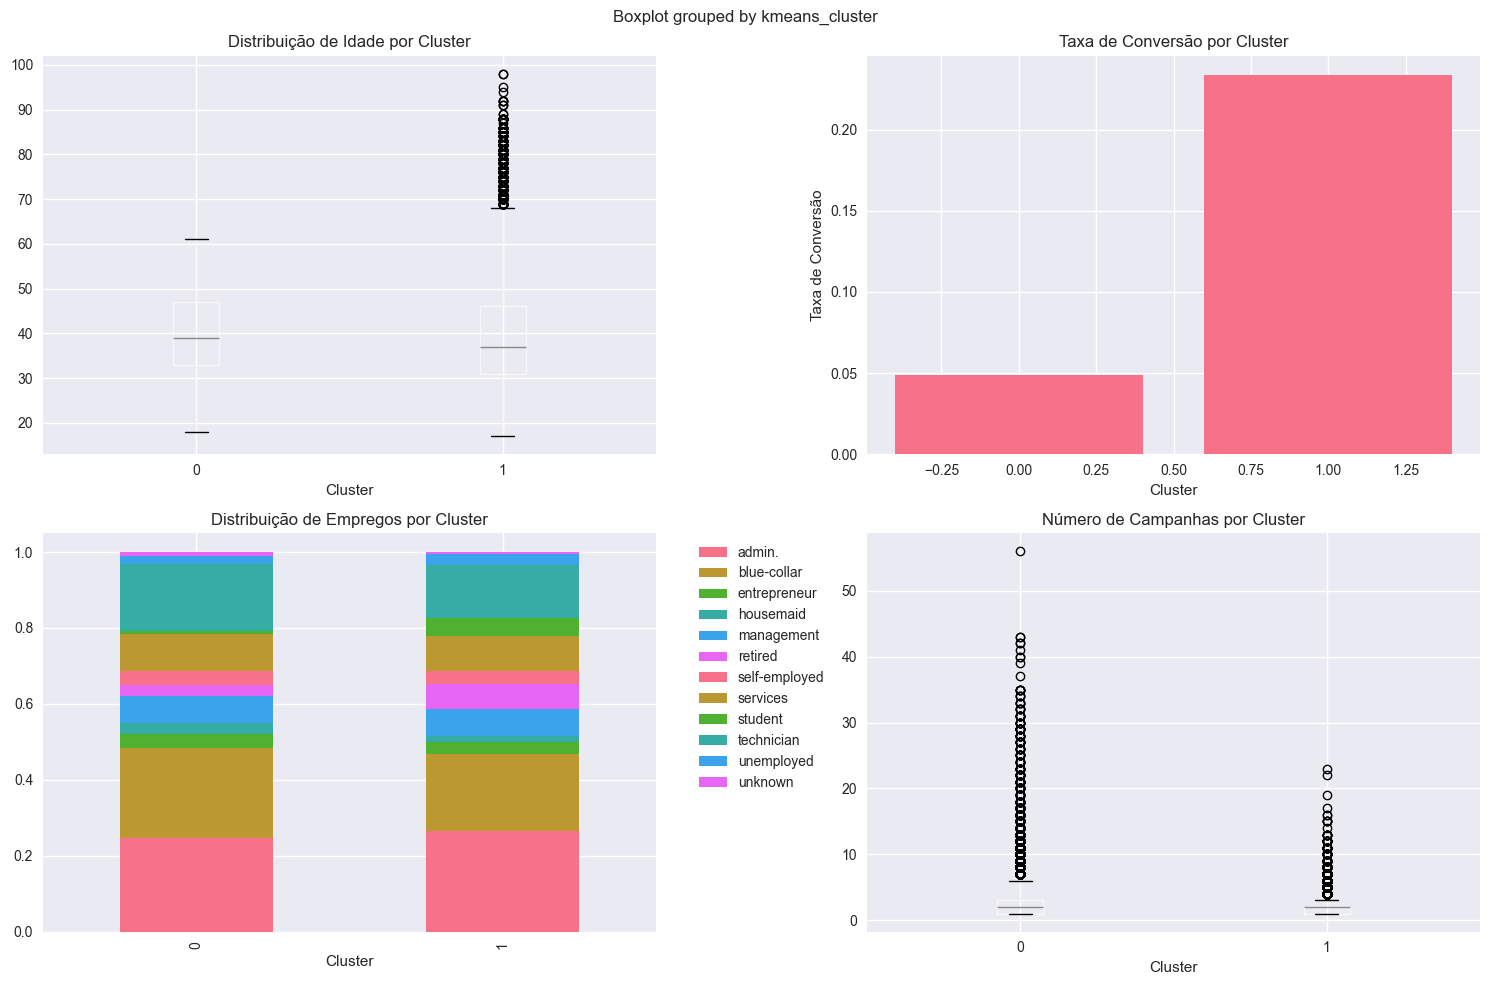

In [19]:
# Interpretação dos clusters - usando K-Means como exemplo principal
print("=== ANÁLISE DETALHADA DOS CLUSTERS (K-MEANS) ===")

# Estatísticas por cluster
cluster_analysis = df_results.groupby('kmeans_cluster').agg({
    'age': ['mean', 'std'],
    'job': lambda x: x.mode().iloc[0],  # moda
    'marital': lambda x: x.mode().iloc[0],
    'education': lambda x: x.mode().iloc[0],
    'housing': lambda x: (x == 'yes').mean(),  # proporção com empréstimo habitação
    'loan': lambda x: (x == 'yes').mean(),     # proporção com empréstimo pessoal
    'campaign': ['mean', 'std'],
    'previous': ['mean', 'std'],
    'emp.var.rate': 'mean',
    'cons.price.idx': 'mean',
    'cons.conf.idx': 'mean',
    'y': lambda x: (x == 'yes').mean()  # taxa de conversão
}).round(3)

print("Características médias por cluster:")
print(cluster_analysis)

# Visualização das características principais
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Idade por cluster
df_results.boxplot(column='age', by='kmeans_cluster', ax=axes[0,0])
axes[0,0].set_title('Distribuição de Idade por Cluster')
axes[0,0].set_xlabel('Cluster')

# Taxa de conversão por cluster
conversion_rates = df_results.groupby('kmeans_cluster')['y'].apply(lambda x: (x == 'yes').mean())
axes[0,1].bar(conversion_rates.index, conversion_rates.values)
axes[0,1].set_title('Taxa de Conversão por Cluster')
axes[0,1].set_xlabel('Cluster')
axes[0,1].set_ylabel('Taxa de Conversão')

# Distribuição de empregos por cluster
job_dist = pd.crosstab(df_results['kmeans_cluster'], df_results['job'], normalize='index')
job_dist.plot(kind='bar', stacked=True, ax=axes[1,0])
axes[1,0].set_title('Distribuição de Empregos por Cluster')
axes[1,0].set_xlabel('Cluster')
axes[1,0].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

# Número de campanhas por cluster
df_results.boxplot(column='campaign', by='kmeans_cluster', ax=axes[1,1])
axes[1,1].set_title('Número de Campanhas por Cluster')
axes[1,1].set_xlabel('Cluster')

plt.tight_layout()
plt.show()

### **4.3 Conclusões e Insights de Negócio**

Com base na análise dos clusters, podemos identificar diferentes perfis de clientes e suas implicações para estratégias de marketing.

In [21]:
# Insights de negócio baseados nos clusters
print("=== INSIGHTS DE NEGÓCIO ===")
print()

# Criar perfis descritivos para cada cluster
for cluster_id in sorted(df_results['kmeans_cluster'].unique()):
    cluster_data = df_results[df_results['kmeans_cluster'] == cluster_id]
    cluster_size = len(cluster_data)
    
    print(f"📊 CLUSTER {cluster_id} ({cluster_size} clientes - {cluster_size/len(df_results)*100:.1f}%)")
    print("-" * 50)
    
    # Demografia
    avg_age = cluster_data['age'].mean()
    main_job = cluster_data['job'].mode().iloc[0]
    main_education = cluster_data['education'].mode().iloc[0]
    main_marital = cluster_data['marital'].mode().iloc[0]
    
    print(f"Demografia:")
    print(f"  - Idade média: {avg_age:.1f} anos")
    print(f"  - Profissão principal: {main_job}")
    print(f"  - Educação principal: {main_education}")
    print(f"  - Estado civil principal: {main_marital}")
    
    # Comportamento financeiro
    housing_rate = (cluster_data['housing'] == 'yes').mean()
    loan_rate = (cluster_data['loan'] == 'yes').mean()
    
    print(f"Comportamento Financeiro:")
    print(f"  - % com empréstimo habitação: {housing_rate*100:.1f}%")
    print(f"  - % com empréstimo pessoal: {loan_rate*100:.1f}%")
    
    # Comportamento na campanha
    avg_campaign = cluster_data['campaign'].mean()
    avg_previous = cluster_data['previous'].mean()
    conversion_rate = (cluster_data['y'] == 'yes').mean()
    
    print(f"Comportamento na Campanha:")
    print(f"  - Contatos médios na campanha: {avg_campaign:.1f}")
    print(f"  - Contatos anteriores médios: {avg_previous:.1f}")
    print(f"  - Taxa de conversão: {conversion_rate*100:.1f}%")
    print()

# Recomendações estratégicas
print("🎯 RECOMENDAÇÕES ESTRATÉGICAS:")
print("=" * 50)
print()

# Identificar cluster com maior taxa de conversão
best_cluster = df_results.groupby('kmeans_cluster')['y'].apply(lambda x: (x == 'yes').mean()).idxmax()
best_conversion = df_results.groupby('kmeans_cluster')['y'].apply(lambda x: (x == 'yes').mean()).max()

print(f"1. CLUSTER PRIORITÁRIO: Cluster {best_cluster}")
print(f"   - Maior taxa de conversão: {best_conversion*100:.1f}%")
print(f"   - Foco principal dos recursos de marketing")
print()

# Identificar cluster com menor taxa mas maior volume
cluster_sizes = df_results['kmeans_cluster'].value_counts()
largest_cluster = cluster_sizes.idxmax()
largest_size = cluster_sizes.max()

print(f"2. CLUSTER DE VOLUME: Cluster {largest_cluster}")
print(f"   - Maior volume de clientes: {largest_size} ({largest_size/len(df_results)*100:.1f}%)")
print(f"   - Potencial para campanhas de massa personalizada")
print()

print("3. ESTRATÉGIAS GERAIS:")
print("   - Personalizar abordagens por cluster")
print("   - Ajustar número de contatos baseado no perfil")
print("   - Desenvolver produtos específicos para cada segmento")
print("   - Otimizar timing das campanhas por perfil demográfico")

=== INSIGHTS DE NEGÓCIO ===

📊 CLUSTER 0 (26960 clientes - 65.5%)
--------------------------------------------------
Demografia:
  - Idade média: 40.2 anos
  - Profissão principal: admin.
  - Educação principal: university.degree
  - Estado civil principal: married
Comportamento Financeiro:
  - % com empréstimo habitação: 50.3%
  - % com empréstimo pessoal: 15.1%
Comportamento na Campanha:
  - Contatos médios na campanha: 2.8
  - Contatos anteriores médios: 0.0
  - Taxa de conversão: 4.9%

📊 CLUSTER 1 (14228 clientes - 34.5%)
--------------------------------------------------
Demografia:
  - Idade média: 39.7 anos
  - Profissão principal: admin.
  - Educação principal: university.degree
  - Estado civil principal: married
Comportamento Financeiro:
  - % com empréstimo habitação: 56.4%
  - % com empréstimo pessoal: 15.2%
Comportamento na Campanha:
  - Contatos médios na campanha: 2.1
  - Contatos anteriores médios: 0.5
  - Taxa de conversão: 23.4%

🎯 RECOMENDAÇÕES ESTRATÉGICAS:

1. CLUS

## **Conclusões Finais**

O projeto de clustering aplicado ao dataset Bank Marketing revelou insights valiosos sobre diferentes perfis de clientes. A análise demonstrou que:

1. **Algoritmos diferentes** capturam padrões distintos nos dados.
2. **K-Means** ofereceu a melhor interpretabilidade para segmentação de clientes, permitindo a identificação de grupos distintos com características bem definidas.
3. **DBSCAN** foi eficaz na identificação de grupos de alta densidade e outliers, que podem representar nichos específicos ou comportamentos atípicos de clientes.
4. **Clustering Hierárquico**, embora computacionalmente mais intensivo, confirmou em grande parte a estrutura de agrupamento encontrada pelo K-Means, fornecendo uma validação adicional.

Os perfis de clientes identificados através dos clusters podem orientar **estratégias de marketing personalizadas**, direcionando ofertas e comunicações mais relevantes para cada segmento. Adicionalmente, os insights podem ser aplicados no **desenvolvimento de novos produtos e serviços** financeiros e na **otimização de campanhas de telemarketing futuras**, visando aumentar a eficiência operacional e as taxas de conversão do banco.

A documentação detalhada das interações com a IA, que auxiliaram em diversas etapas deste projeto (desde o entendimento do negócio até a avaliação dos modelos), será fornecida em um arquivo Markdown separado, conforme especificado.

**Próximos passos para a Fase 3:**
- Correção e refinamento de quaisquer limitações ou sugestões da IA que necessitem de ajuste.
- Aprofundamento na análise dos algoritmos e seus parâmetros, buscando otimizar ainda mais os resultados.
- Análise mais detalhada dos perfis de clientes de cada cluster, cruzando com outras informações de negócio disponíveis.
- Desenvolvimento de recomendações estratégicas acionáveis e detalhadas para as áreas de marketing e produtos do banco.
- Avaliação do impacto potencial das estratégias propostas.
